In [3]:
import pandas as pd
import matplotlib.pyplot as plt

flow = pd.read_csv("data/processed/flow_15min.csv", parse_dates=["interval"])
print(flow.shape)
print(flow.describe())
print("Stations:", flow["stationID"].nunique())
print("Date range:", flow["interval"].min(), "to", flow["interval"].max())

(152722, 4)
           stationID                       interval         inflow  \
count  152722.000000                         152722  152722.000000   
mean       39.770937  2019-01-13 15:00:42.211992832     192.034003   
min         0.000000            2019-01-01 02:00:00       0.000000   
25%        20.000000            2019-01-07 10:15:00      59.000000   
50%        39.000000            2019-01-13 15:00:00     128.000000   
75%        60.000000            2019-01-19 20:00:00     230.000000   
max        80.000000            2019-01-25 23:45:00    4207.000000   
std        23.412964                            NaN     253.185774   

             outflow  
count  152722.000000  
mean      191.913542  
min         0.000000  
25%        55.000000  
50%       125.000000  
75%       235.000000  
max      4876.000000  
std       245.511925  
Stations: 80
Date range: 2019-01-01 02:00:00 to 2019-01-25 23:45:00


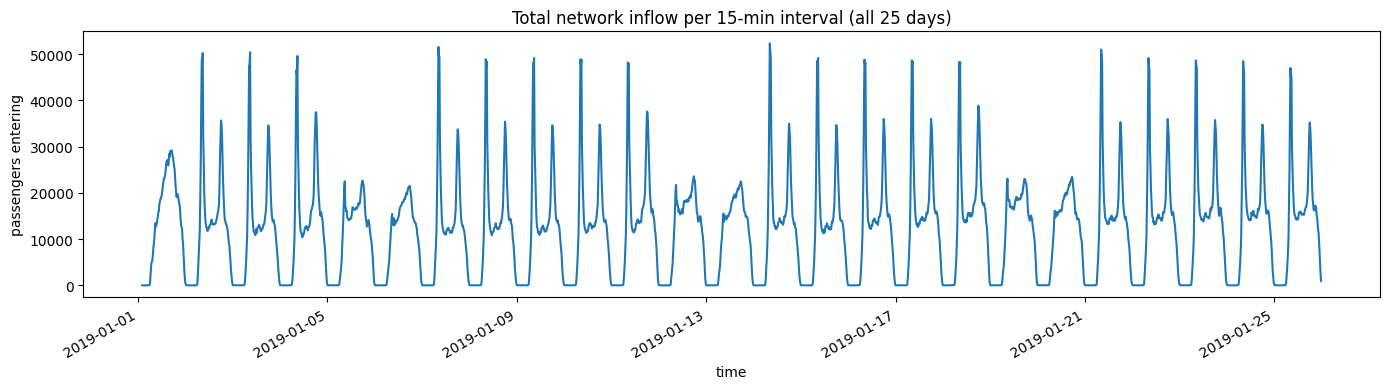

In [4]:
# total network inflow per 15-min interval, across all days
network = flow.groupby("interval")["inflow"].sum()

plt.figure(figsize=(14, 4))
network.plot()
plt.title("Total network inflow per 15-min interval (all 25 days)")
plt.ylabel("passengers entering")
plt.xlabel("time")
plt.tight_layout()
plt.show()

In [5]:
# assign each row to train / val / test by its date
def assign_split(ts):
    day = ts.day
    if day <= 18:
        return "train"
    elif day <= 20:      # 19, 20
        return "val"
    else:                # 21–25
        return "test"

flow["split"] = flow["interval"].apply(assign_split)

# verify the split sizes
print(flow["split"].value_counts())
print(flow.groupby("split")["interval"].agg(["min", "max"]))

split
train    109590
test      30962
val       12170
Name: count, dtype: int64
                      min                 max
split                                        
test  2019-01-21 00:00:00 2019-01-25 23:45:00
train 2019-01-01 02:00:00 2019-01-18 23:45:00
val   2019-01-19 00:00:00 2019-01-20 23:45:00


In [6]:
flow.to_csv("data/processed/flow_15min_split.csv", index=False)
print("Saved with split column:", flow.shape)

Saved with split column: (152722, 5)


In [7]:
flow["hour"] = flow["interval"].dt.hour
flow["minute"] = flow["interval"].dt.minute
flow["dayofweek"] = flow["interval"].dt.dayofweek        # Monday=0 ... Sunday=6
flow["is_weekend"] = (flow["dayofweek"] >= 5).astype(int)  # 1 if Sat/Sun

print(flow[["interval", "hour", "minute", "dayofweek", "is_weekend"]].head())
print(flow[["interval", "hour", "dayofweek", "is_weekend"]].tail())

             interval  hour  minute  dayofweek  is_weekend
0 2019-01-01 05:30:00     5      30          1           0
1 2019-01-01 05:45:00     5      45          1           0
2 2019-01-01 06:00:00     6       0          1           0
3 2019-01-01 06:15:00     6      15          1           0
4 2019-01-01 06:30:00     6      30          1           0
                  interval  hour  dayofweek  is_weekend
152717 2019-01-25 22:45:00    22          4           0
152718 2019-01-25 23:00:00    23          4           0
152719 2019-01-25 23:15:00    23          4           0
152720 2019-01-25 23:30:00    23          4           0
152721 2019-01-25 23:45:00    23          4           0


In [8]:
# CRITICAL: sort by station then time, so "previous row" = previous interval for that station
flow = flow.sort_values(["stationID", "interval"]).reset_index(drop=True)

# lag features: inflow N intervals ago, computed WITHIN each station
for lag in [1, 2, 3, 4]:
    flow[f"inflow_lag_{lag}"] = flow.groupby("stationID")["inflow"].shift(lag)

# rolling mean of the last 4 intervals — also within station, and shifted by 1
# so the current row's value is NOT included (that would leak the answer)
flow["inflow_roll_mean_4"] = (
    flow.groupby("stationID")["inflow"]
        .shift(1)                    # step back so we don't include "now"
        .rolling(4)                  # average of the 4 intervals before now
        .mean()
        .reset_index(level=0, drop=True)
)

# check the result for one station
cols = ["stationID","interval","inflow","inflow_lag_1","inflow_lag_2","inflow_roll_mean_4"]
print(flow[flow["stationID"]==0][cols].head(8))

   stationID            interval  inflow  inflow_lag_1  inflow_lag_2  \
0          0 2019-01-01 05:30:00       0           NaN           NaN   
1          0 2019-01-01 05:45:00       1           0.0           NaN   
2          0 2019-01-01 06:00:00       0           1.0           0.0   
3          0 2019-01-01 06:15:00       1           0.0           1.0   
4          0 2019-01-01 06:30:00      89           1.0           0.0   
5          0 2019-01-01 06:45:00      33          89.0           1.0   
6          0 2019-01-01 07:00:00      35          33.0          89.0   
7          0 2019-01-01 07:15:00      39          35.0          33.0   

   inflow_roll_mean_4  
0                 NaN  
1                 NaN  
2                 NaN  
3                 NaN  
4                0.50  
5               22.75  
6               30.75  
7               39.50  


In [9]:
# how many rows have NaN (from lags/rolling at the start of each station)
print("Before dropping NaN:", flow.shape)
print("Rows with NaN:", flow.isna().any(axis=1).sum())

# drop rows that don't have full lag history
flow_model = flow.dropna().reset_index(drop=True)
print("After dropping NaN:", flow_model.shape)

# confirm split counts still healthy after the drop
print(flow_model["split"].value_counts())

Before dropping NaN: (152722, 14)
Rows with NaN: 320
After dropping NaN: (152402, 14)
split
train    109270
test      30962
val       12170
Name: count, dtype: int64


In [10]:
flow_model.to_csv("data/processed/flow_features.csv", index=False)
print("Saved feature table:", flow_model.shape)
print(flow_model.columns.tolist())

Saved feature table: (152402, 14)
['stationID', 'interval', 'inflow', 'outflow', 'split', 'hour', 'minute', 'dayofweek', 'is_weekend', 'inflow_lag_1', 'inflow_lag_2', 'inflow_lag_3', 'inflow_lag_4', 'inflow_roll_mean_4']
